<a href="https://colab.research.google.com/github/CristianoCoelhoSilva/Python/blob/master/Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [191]:
import numpy as np
import pandas as pd
import seaborn
import matplotlib
import pydotplus
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso#Loading the dataset
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
%matplotlib inline




In [165]:
#Arquivo completo
df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid_limit.csv")

#Removendo as colunas
df.drop(["GENERO","RACA","MES",'ESCOLARIDADE','ESTABELECIMENTO'], axis="columns", inplace=True)
df.drop(["ENTUBADO"], axis="columns", inplace=True)

In [128]:
#df['IDADE'].corr(df['FEBRE'])

In [19]:
#df.corr()

In [20]:
#df.corr().style.format("{:.2}").background_gradient(cmap=plt.get_cmap('coolwarm'), axis=1)

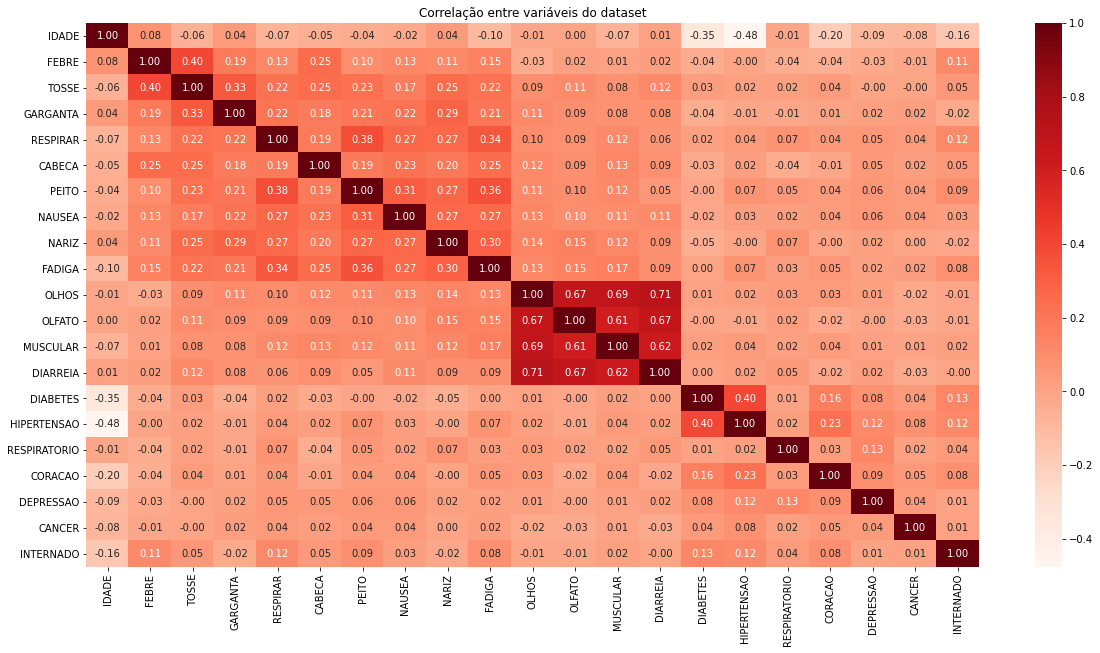

In [129]:
a4_dims = (20, 10)
fig, ax = plt.subplots(figsize=a4_dims)

seaborn.heatmap(df.corr(),
            annot = True,
            fmt = '.2f',
            cmap='Reds')
plt.title('Correlação entre variáveis do dataset')
plt.show()

In [168]:
##Fazendo o holdout

X = df.drop(['INTERNADO'], axis = "columns")
y = df.INTERNADO

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 13)

# Cria nosso pipeline para pré-processamento com imputação, dummização e normalização
encoder_imputer_scaled_transformer = make_column_transformer(
    (make_pipeline(
        (KNNImputer(n_neighbors = 3)),
        (StandardScaler())
    ) , make_column_selector(dtype_include = np.number)),
    (make_pipeline(
        SimpleImputer(strategy = 'most_frequent'),
        OneHotEncoder(handle_unknown = 'ignore'),
    ), make_column_selector(dtype_exclude = np.number)),
    remainder = 'passthrough'
)

encoder_imputer_scaled_transformer.fit(X_train)

X_train_processed = encoder_imputer_scaled_transformer.transform(X_train)
X_test_processed = encoder_imputer_scaled_transformer.transform(X_test)

model  = RandomForestClassifier()
#model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train_processed, y_train)# Mostrando importância de cada feature
#model.feature_importances_

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

Text(0.5, 1.0, 'Importância de cada feature')

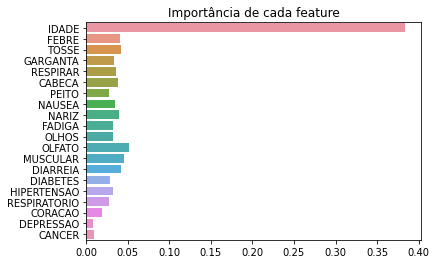

In [131]:
importances = pd.Series(data=model.feature_importances_, index=X.columns)
seaborn.barplot(x=importances, y=importances.index, orient='h').set_title('Importância de cada feature')

In [132]:
#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10)
fit = bestfeatures.fit(X,y)

dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(10,'Score'))  #print 10 best features

          Specs       Score
0         IDADE  539.584100
1         FEBRE    5.516139
4      RESPIRAR    4.578167
9        FADIGA    2.884127
15  HIPERTENSAO    2.503311
6         PEITO    2.403643
12     MUSCULAR    2.211301
14     DIABETES    1.611759
11       OLFATO    1.496799
5        CABECA    1.293303


In [133]:
reg = LassoCV()
reg.fit(X, y)
print("Best alpha using built-in LassoCV: %f" % reg.alpha_)
print("Best score using built-in LassoCV: %f" %reg.score(X,y))
coef = pd.Series(reg.coef_, index = X.columns)

Best alpha using built-in LassoCV: 0.000687
Best score using built-in LassoCV: 0.071506


Text(0.5, 1.0, 'Feature importance using Lasso Model')

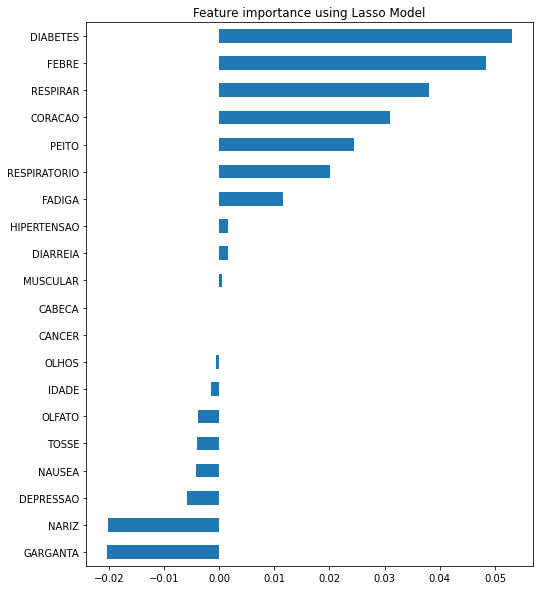

In [134]:
imp_coef = coef.sort_values()
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Feature importance using Lasso Model")

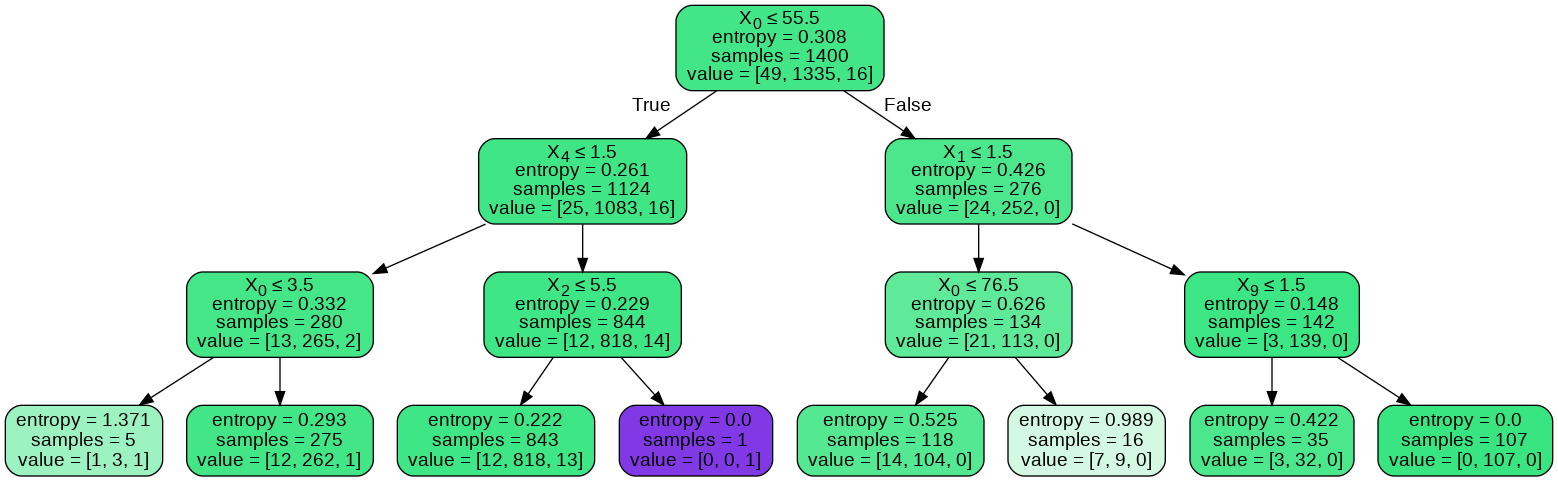

In [190]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf = clf.fit(X_train, y_train) # o método fit "treina o modelo"

preds = clf.predict(X_test)

confusion_matrix(y_test, preds)

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
Image(graph.create_png())

## Cross Validation

In [135]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
from sklearn.model_selection import KFold

In [136]:
X_processed = encoder_imputer_scaled_transformer.fit_transform(X)

In [143]:
import seaborn
import matplotlib.pyplot as plt

results_cross_validation = []
for k in range(3, 51):
  for time in range(30):
    kf = KFold(n_splits=k, shuffle=True).split(X_processed)
    #scores = cross_val_score(model, X_processed, y, cv=kf, scoring='accuracy')
    scores = cross_val_score(model, X_processed, y, cv=kf, scoring='precision_macro')
    results_cross_validation = results_cross_validation + [[k, time, np.mean(scores)]]

/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.6/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Pr

KeyboardInterrupt: ignored

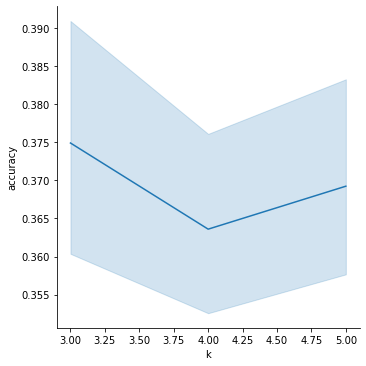

In [150]:
df = pd.DataFrame(results_cross_validation,columns=['k','time_id', 'accuracy'])

seaborn.relplot(data = df,
                x = 'k',
                y = 'accuracy',
                kind = 'line')
plt.show()

In [154]:
results = pd.DataFrame(columns=['n_neighbors', 'accuracy'])

for n_neighbors in range(1, 31):
  knn = KNeighborsClassifier(n_neighbors = n_neighbors)
  scores = cross_val_score(knn, X_train_processed, y_train, cv=9, scoring='accuracy')
  results = results.append({'n_neighbors' : n_neighbors, 'accuracy' : np.mean(scores)}, ignore_index = True)
  
results

,n_neighbors,accuracy
0,1.0,0.917861
1,2.0,0.906419
2,3.0,0.951438
3,4.0,0.951443
4,5.0,0.953580
5,6.0,0.953580
6,7.0,0.953575
7,8.0,0.953575
8,9.0,0.953575
9,10.0,0.953575


O k que maximiza a acurácia no conjunto de treinamento é: 5


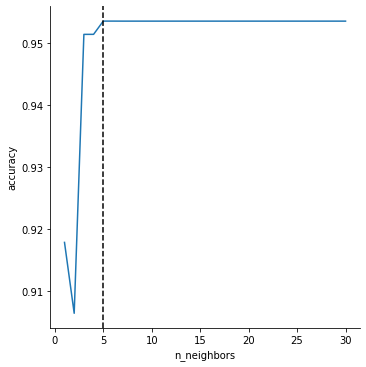

In [155]:
import seaborn
import matplotlib.pyplot as plt

melhor_k = int(results[results.accuracy == results.accuracy.max()]['n_neighbors'].values[0])

seaborn.relplot(data = results,
                x = 'n_neighbors',
                y = 'accuracy',
                kind = 'line')
plt.axvline(x=melhor_k, color="black", linestyle= "--")

print("O k que maximiza a acurácia no conjunto de treinamento é: {}".format(melhor_k))

## Script

In [156]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pipeline_estendido = Pipeline([
    ("pre_process", make_column_transformer(
                              (Pipeline([
                                  ('imputer', KNNImputer(n_neighbors = 3)),
                                  ('scaler', StandardScaler())
                              ]) , make_column_selector(dtype_include = np.number)),
                              (Pipeline([
                                  ("imputer", SimpleImputer(strategy = 'most_frequent', fill_value = "unknown")),
                                  ("encoder", OneHotEncoder(handle_unknown = 'ignore'))
                              ]), make_column_selector(dtype_exclude = np.number))
                          )),
    ##("knn", KNeighborsClassifier())
    ##
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=0))                           
])

In [93]:
import pprint as pp

pp.pprint(sorted(pipeline_estendido.get_params().keys()))

['memory',
 'pre_process',
 'pre_process__n_jobs',
 'pre_process__pipeline-1',
 'pre_process__pipeline-1__imputer',
 'pre_process__pipeline-1__imputer__add_indicator',
 'pre_process__pipeline-1__imputer__copy',
 'pre_process__pipeline-1__imputer__metric',
 'pre_process__pipeline-1__imputer__missing_values',
 'pre_process__pipeline-1__imputer__n_neighbors',
 'pre_process__pipeline-1__imputer__weights',
 'pre_process__pipeline-1__memory',
 'pre_process__pipeline-1__scaler',
 'pre_process__pipeline-1__scaler__copy',
 'pre_process__pipeline-1__scaler__with_mean',
 'pre_process__pipeline-1__scaler__with_std',
 'pre_process__pipeline-1__steps',
 'pre_process__pipeline-1__verbose',
 'pre_process__pipeline-2',
 'pre_process__pipeline-2__encoder',
 'pre_process__pipeline-2__encoder__categories',
 'pre_process__pipeline-2__encoder__drop',
 'pre_process__pipeline-2__encoder__dtype',
 'pre_process__pipeline-2__encoder__handle_unknown',
 'pre_process__pipeline-2__encoder__sparse',
 'pre_process__pi

In [120]:
#Knn
#param_grid_estendido = {
#    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
#    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
#    "knn__n_neighbors": range(1, 2)
#}

#Decision Tree
param_grid_estendido = {
    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
    "tree__min_samples_leaf": range(1, 3)
}

classificador_estendido = GridSearchCV(estimator = pipeline_estendido,
                                       param_grid = param_grid_estendido,
                                       scoring = "accuracy",
                                       cv = 5,
                                       refit = True)

In [121]:
classificador_estendido.fit(X_train, y_train)

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_split.py:667: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  % (min_groups, self.n_splits)), UserWarning)


GridSearchCV(cv=5, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('pre_process',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='drop',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('imputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                                    

In [192]:
print("Melhor parâmetro do modelo knn: ")
print(classificador_estendido.best_params_)

print("Desempenho médio no fold de teste: ")
print(np.mean(classificador_estendido.cv_results_['mean_test_score']))

Melhor parâmetro do modelo knn: 
{'pre_process__pipeline-1__imputer__n_neighbors': 1, 'pre_process__pipeline-2__imputer__strategy': 'most_frequent', 'tree__min_samples_leaf': 1}
Desempenho médio no fold de teste: 
0.9451345470643574
